[Sascha Spors](https://orcid.org/0000-0001-7225-9992),
Professorship Signal Theory and Digital Signal Processing,
[Institute of Communications Engineering (INT)](https://www.int.uni-rostock.de/),
Faculty of Computer Science and Electrical Engineering (IEF),
[University of Rostock, Germany](https://www.uni-rostock.de/en/)

# Tutorial Signals and Systems (Signal- und Systemtheorie)

Summer Semester 2022 (Bachelor Course #24015)

- lecture: https://github.com/spatialaudio/signals-and-systems-lecture
- tutorial: https://github.com/spatialaudio/signals-and-systems-exercises

Feel free to contact lecturer [frank.schultz@uni-rostock.de](https://orcid.org/0000-0002-3010-0294)

## Solving an Electric System's 2nd-order ODE

create plots for `tutorial_extended_latex_deu/laplace_transform_839973EF5D.tex`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy.signal as signal

## Plots for Specific Manually Derived Results

See `solving_2nd_order_ode.tex` for manual calculus

All results are valid for $t\geq 0$, functions are zero for $t<0$.

### Impulse Response
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = x
\end{equation}
for $x = \delta(t)$
\begin{equation}
y_p = h = \frac{25}{16} \mathrm{e}^{-\frac{3}{4} t} \sin(t)
\end{equation}

### Step Response
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = x
\end{equation}
for $x = 1$, $\dot{y}(0)=0$, $y(0)=0$
\begin{equation}
y_p + y_h = h_\epsilon = 1 - \mathrm{e}^{-\frac{3}{4} t} \left(\frac{3}{4} \sin(t) + \cos(t)\right)
\end{equation}

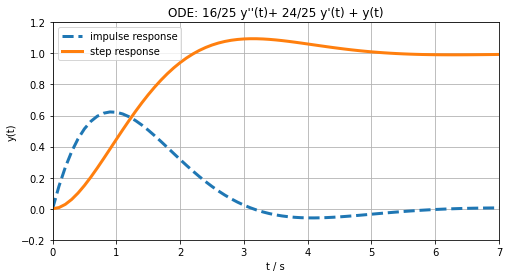

In [2]:
t = np.arange(0, 10, 0.1)
h = 25/16 * np.exp(-3/4*t) * np.sin(t)
he = 1 + np.exp(-3/4*t) * (-3/4*np.sin(t) - np.cos(t))
plt.figure(figsize=(8, 4))
plt.plot(t, h, '--', label='impulse response', lw=3)
plt.plot(t, he, label='step response', lw=3)
plt.xlabel('t / s')
plt.ylabel('y(t)')
plt.grid(True)
plt.xlim((0, 7))
plt.ylim((-0.2, 1.2))
plt.title('ODE: 16/25 y\'\'(t)+ 24/25 y\'(t) + y(t)')
plt.legend()
plt.savefig('impulse_step_response_839973EF5D.pdf')

### Signal Parts for Step Response with Zero Initial Conditions 
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = x
\end{equation}
for $x=1$, $\dot{y}(0)=0$, $y(0)=0$
\begin{equation}
h_\epsilon = 1 - \mathrm{e}^{-\frac{3}{4} t} \left(\frac{3}{4} \sin(t) + \cos(t)\right)
\end{equation}
Superposition of black, green and red graph yield result in orange graph.



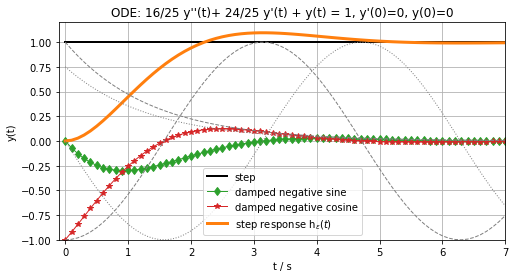

In [3]:
t = np.arange(0, 10, 0.1)
he = 1 + np.exp(-3/4*t) * (-3/4*np.sin(t) - np.cos(t))
heps = t*0 + 1
hsin = -3/4 * np.sin(t) * np.exp(-3/4*t)
hcos = -np.cos(t) * np.exp(-3/4*t)
hexp11 = +np.exp(-3/4*t)
hexp34 = +3/4*np.exp(-3/4*t)
plt.figure(figsize=(8, 4))
plt.plot(t, heps, '-', label='step', lw=2, color='k')
plt.plot(t, hsin, '-d', label='damped negative sine', lw=1, color='C2')
plt.plot(t, hcos, '-*', label='damped negative cosine', lw=1, color='C3')
plt.plot(t, he, '-', label='step response h$_\epsilon(t)$', lw=3, color='C1')
plt.plot(t, hexp11, '--', label='', lw=1, color='gray')
plt.plot(t, -np.cos(t), '--', label='', lw=1, color='gray')
plt.plot(t, hexp34, ':', label='', lw=1, color='gray')
plt.plot(t, -np.sin(t), ':', label='', lw=1, color='gray')
plt.xlabel('t / s')
plt.ylabel('y(t)')
plt.grid(True)
plt.xlim((-0.1, 7))
plt.ylim((-1, 1.2))
plt.title('ODE: 16/25 y\'\'(t)+ 24/25 y\'(t) + y(t) = 1, y\'(0)=0, y(0)=0')
plt.legend()
plt.savefig('step_response_parts_839973EF5D.pdf')

### Signal Parts for Initial Conditions Only
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = 0
\end{equation}
for $\dot{y}(0)=2$, $y(0)=1$
\begin{equation}
y = \mathrm{e}^{-\frac{3}{4} t} \left( \frac{11}{4} \sin(t) + \cos(t)\right)
\end{equation}
Superposition of green/diamonds and red/stars graph yields final result depicted in brown.

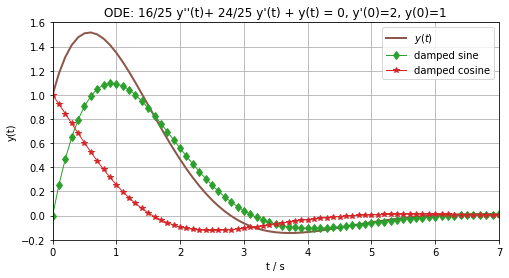

In [4]:
t = np.arange(0, 10, 0.1)
hdec = np.exp(-3/4*t) * (11/4*np.sin(t) + np.cos(t))
hcos = +np.exp(-3/4*t) * np.cos(t)
hsin = +11/4*np.exp(-3/4*t) * np.sin(t)
plt.figure(figsize=(8, 4))
plt.plot(t, hdec, '-', label='$y(t)$', lw=2, color='C5')
plt.plot(t, hsin, '-d', label='damped sine', lw=1, color='C2')
plt.plot(t, hcos, '-*', label='damped cosine', lw=1, color='C3')
plt.xlabel('t / s')
plt.ylabel('y(t)')
plt.grid(True)
plt.xlim((0, 7))
plt.ylim((-0.2, 1.6))
plt.title('ODE: 16/25 y\'\'(t)+ 24/25 y\'(t) + y(t) = 0, y\'(0)=2, y(0)=1')
plt.legend()
plt.savefig('initial_conditions_response_parts_839973EF5D.pdf')

### Signal Parts for Step Response with Initial Conditions
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = x
\end{equation}
for $x=1$, $\dot{y}(0)=2$, $y(0)=1$
\begin{equation}
y = 1+\mathrm{e}^{-\frac{3}{4} t} \, 2 \sin(t)
\end{equation}

Superposition of black and green/diamond graphs yield the final result shown in magenta.

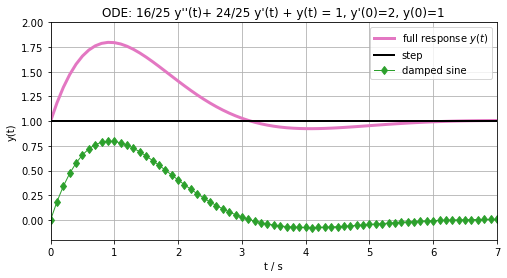

In [5]:
t = np.arange(0, 10, 0.1)
hstep = t*0+1
hsin = 2*np.exp(-3/4*t) * np.sin(t)
hresp = hstep + hsin
plt.figure(figsize=(8, 4))
plt.plot(t, hresp, '-', label='full response $y(t)$', lw=3, color='C6')
plt.plot(t, hstep, '-', label='step', lw=2, color='k')
plt.plot(t, hsin, '-d', label='damped sine', lw=1, color='C2')
plt.xlabel('t / s')
plt.ylabel('y(t)')
plt.grid(True)
plt.xlim((0, 7))
plt.ylim((-0.2, 2))
plt.title('ODE: 16/25 y\'\'(t)+ 24/25 y\'(t) + y(t) = 1, y\'(0)=2, y(0)=1')
plt.legend()
plt.savefig('response_full_839973EF5D.pdf')

### Signal Parts for Sine Excitation Response with Zero Initial Conditions
\begin{equation}
\frac{16}{25} \ddot{y} + \frac{24}{25} \dot{y} + y = \sin(t)
\end{equation}
for $\dot{y}(0)=0$, $y(0)=0$
\begin{equation}
y = \frac{25}{73} \mathrm{e}^{-\frac{3}{4} t} \sin(t) +
\frac{200}{219} \mathrm{e}^{-\frac{3}{4} t} \cos(t) +
\frac{25}{73} \sin(t) -
\frac{200}{219} \cos(t)
\end{equation}


0.9753428933010881 1.2120256565243244


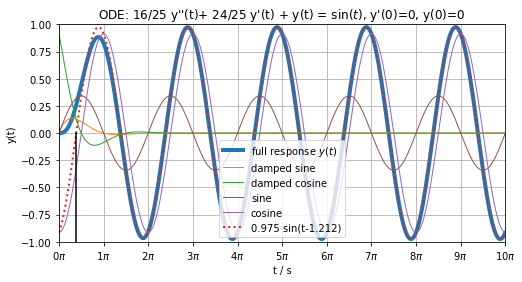

In [6]:
t = np.arange(0, 10*np.pi, 0.1)
A = 25/3/np.sqrt(73)
phi = np.arctan((200/219)/(25/73))
phi = np.arctan(8/3)  # nicer
hrefsine = A * np.sin(t-phi)
hsin1 = 25/73 * np.exp(-3/4*t) * np.sin(t)
hcos1 = 200/219 * np.exp(-3/4*t) * np.cos(t)
hsin2 = 25/73 * np.sin(t)
hcos2 = -200/219 * np.cos(t)
hresp = hsin1 + hcos1 + hsin2 + hcos2
plt.figure(figsize=(8, 4))
plt.plot(t, hresp, '-', label='full response $y(t)$', lw=4, color='C0')
plt.plot(t, hsin1, '-', label='damped sine', lw=1, color='C1')
plt.plot(t, hcos1, '-', label='damped cosine', lw=1, color='C2')
plt.plot(t, hsin2, '-', label='sine', lw=1, color='C5')
plt.plot(t, hcos2, '-', label='cosine', lw=1, color='C4')
plt.plot(t, hrefsine, ':', label='0.975 sin(t-1.212)', lw=2, color='C3')
plt.plot([phi, phi], [-1, 0], color='k')
plt.xlabel('t / s')
plt.ylabel('y(t)')
plt.grid(True)
plt.xlim((0, 30))
plt.ylim((-1, 1))
tick = np.arange(0, 11)
tick_label = tick.astype(str)
s = '$\pi$'
tick_label = [tick + s for tick in tick_label]
plt.xticks(tick*np.pi, tick_label)
plt.title('ODE: 16/25 y\'\'(t)+ 24/25 y\'(t) + y(t) = $\sin(t)$, y\'(0)=0, y(0)=0')
plt.legend(loc='lower center')
plt.savefig('sine_excitation_response_839973EF5D.pdf')
print(A, phi)

## Sympy Computations

with code taken from 
https://github.com/spatialaudio/signals-and-systems-lecture/blob/master/systems_time_domain/network_analysis.ipynb

In [7]:
sp.init_printing()
t, L, R, C = sp.symbols('t L R C', real=True)
x = sp.Function('x')(t)
y = sp.Function('y')(t)
ode = sp.Eq(L*C*y.diff(t, 2) + R*C*y.diff(t) + y, x)
RLC = {R: 3, L: 2, C: sp.Rational('0.32')}  # specific example

### Impulse Response / Task a

{C1: 0, C2: 0}
h(t) is the particular solution yp or the full solution y for zero-initial conditions using the lhs limit:


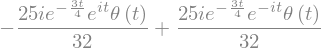

In [8]:
h_ynyp = sp.dsolve(
    ode.subs(x, sp.DiracDelta(t)).subs(y, sp.Function('h')(t)))
integration_constants = sp.solve((
    # here initial condition y(0-)=0
    h_ynyp.rhs.limit(t, 0, '-').subs(RLC) - 0,
    h_ynyp.rhs.diff(t).limit(t, 0, '-').subs(RLC) - 0),  # here initial condition y'(0-)=0
    ['C1', 'C2'])
print(integration_constants)
h = h_ynyp.subs(integration_constants)
print('h(t) is the particular solution yp or the full solution y for zero-initial conditions using the lhs limit:')
sp.trigsimp(h.rhs.subs(RLC)).expand()

This resolves to $h(t) = \frac{25}{16} \cdot \mathrm{e}^{-\frac{3}{4} t} \sin(t)$ for $t\geq0$

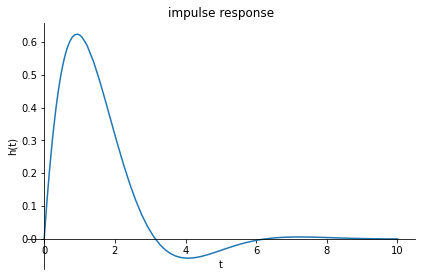

In [9]:
sp.plot(h.rhs.subs(RLC), (t, 0, 10), ylabel=r'h(t)',
        title='impulse response', axis_center=(0, 0))

### Step Response / Task b

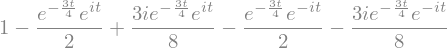

In [10]:
heps_ynyp = sp.dsolve(
    ode.subs(x, 1).subs(y, sp.Function('heps')(t)))

integration_constants = sp.solve((
    heps_ynyp.rhs.limit(t, 0, '+-').subs(RLC) -
    0,  # here initial condition y(0)=0
    heps_ynyp.rhs.diff(t).limit(t, 0, '+-').subs(RLC) - 0),  # here initial condition y'(0)=0
    ['C1', 'C2'])

heps = heps_ynyp.subs(integration_constants)
sp.trigsimp(heps.rhs.subs(RLC)).expand()

This resolves to $h_\epsilon(t) = 1 - \mathrm{e}^{-\frac{3}{4} t} \cdot
\left(\frac{3}{4} \sin(t) + \cos(t)\right)$ for $t \geq 0$

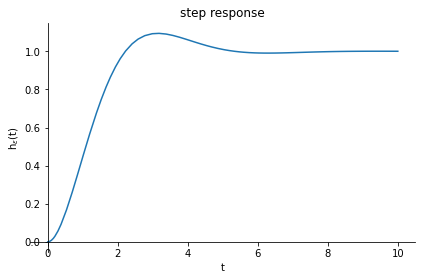

In [11]:
sp.plot(heps.rhs.subs(RLC), (t, 0, 10), ylabel=r'h$_\epsilon$(t)',
        title='step response', axis_center=(0, 0))

### No Excitation and Non-Zero Initial Condition / Task c

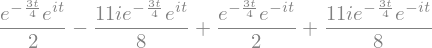

In [12]:
ynyp = sp.dsolve(
    ode.subs(x, 0).subs(y, sp.Function('y')(t)))

integration_constants = sp.solve((
    ynyp.rhs.limit(t, 0, '+-').subs(RLC) - 1,  # here initial condition y(0)=1
    ynyp.rhs.diff(t).limit(t, 0, '+-').subs(RLC) - 2),  # here initial condition y'(0)=2
    ['C1', 'C2'])

y = ynyp.subs(integration_constants)
sp.trigsimp(y.rhs.subs(RLC)).expand()

This resolves to $y(t) = \mathrm{e}^{-\frac{3}{4} t} \cdot \left( \frac{11}{4} \sin(t) + \cos(t)\right)$ for $t\geq 0$

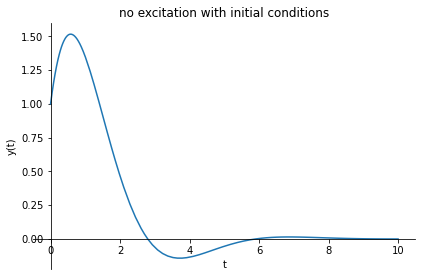

In [13]:
sp.plot(y.rhs.subs(RLC), (t, 0, 10), ylabel=r'y(t)',
        title='no excitation with initial conditions', axis_center=(0, 0))

### Step Excitation and Non-Zero Initial Condition / Task d

In [14]:
ynyp = sp.dsolve(
    ode.subs(x, 1).subs(y, sp.Function('y')(t)))

integration_constants = sp.solve((
    ynyp.rhs.limit(t, 0, '+-').subs(RLC) - 1,  # here initial condition y(0)=1
    ynyp.rhs.diff(t).limit(t, 0, '+-').subs(RLC) - 2),  # here initial condition y'(0)=2
    ['C1', 'C2'])

y = ynyp.subs(integration_constants)
sp.trigsimp(y.rhs.subs(RLC)).expand()

This resolves to $y(t) = 1+\mathrm{e}^{-\frac{3}{4} t} \, 2 \sin(t)$ for $t \geq 0$

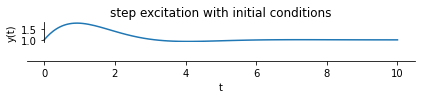

In [15]:
sp.plot(y.rhs.subs(RLC), (t, 0, 10), ylabel=r'y(t)',
        title='step excitation with initial conditions', axis_center=(0, 0))

### Sine Excitation / Task e

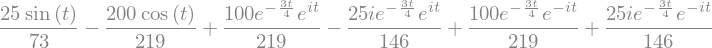

In [16]:
hsin_ynyp = sp.dsolve(
    ode.subs(x, sp.sin(t)).subs(y, sp.Function('hsin')(t)))

integration_constants = sp.solve((
    hsin_ynyp.rhs.limit(t, 0, '+-').subs(RLC) -
    0,  # here initial condition y(0)=0
    hsin_ynyp.rhs.diff(t).limit(t, 0, '+-').subs(RLC) - 0),  # here initial condition y'(0)=0
    ['C1', 'C2'])

hsin = hsin_ynyp.subs(integration_constants)
sp.trigsimp(hsin.rhs.subs(RLC)).expand()

$y(t) = \frac{25}{73} \mathrm{e}^{-\frac{3}{4} t} \sin(t) +
\frac{200}{219} \mathrm{e}^{-\frac{3}{4} t} \cos(t) +
\frac{25}{73} \sin(t) -
\frac{200}{219} \cos(t)$ for $t\geq 0$

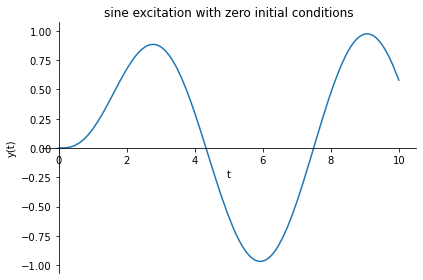

In [17]:
sp.plot(hsin.rhs.subs(RLC), (t, 0, 10), ylabel=r'y(t)',
        title='sine excitation with zero initial conditions', axis_center=(0, 0))

### Transfer Function

Transfer function is the Laplace transform of the impulse response $h(t)$

\begin{align}
H(s) = \mathcal{L}\{h(t)\}= \int\limits_{-\infty}^{\infty} h(t) \mathrm{e}^{-s t} \mathrm{d} t = \frac{1}{\frac{16}{25} s^2 + \frac{24}{25} s + 1}
\end{align}

Since $h(t)$ starts at 0 only, we only need to integrate from $0$ to $\infty$.

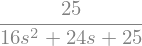

In [18]:
s = sp.symbols('s')
H = sp.Function('H')(s)
H = sp.integrate(h.rhs.subs(RLC)*sp.exp(-s*t),
                 (t, 0, sp.oo), conds='none').simplify()
H

### Frequency Response

For $s = \mathrm{j}\omega$ we evaluate the frequency response (i.e. the **steady state** with respect to amplitude and phase change between output and input of the system/ODE). We can do this for every desired angular frequency $\omega$.

So let us plot amplitude (magnitude) and phase over $\omega$.

In [19]:
w = sp.symbols('omega', real=True)
Hjw = H.subs(s, sp.I * w)

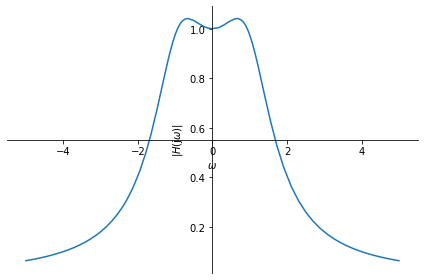

In [20]:
sp.plot(sp.Abs(H.subs(s, sp.I*w)), (w, -5, 5),
        ylabel=r'$|H(\mathrm{j} \omega)|$',
        xlabel=r'$\omega$', center=(0, 0))

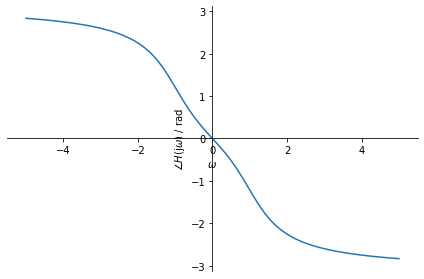

In [21]:
sp.plot(sp.arg(H.subs(s, sp.I*w)), (w, -5, 5),
        ylabel=r'$\angle H(\mathrm{j} \omega)$ / rad',
        xlabel=r'$\omega$', center=(0, 0))

Magnitude at $\omega=1$

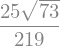

In [22]:
sp.Abs(Hjw.subs(w, 1))

Phase in radian at $\omega=1$

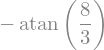

In [23]:
sp.arg(Hjw.subs(w, 1))

In [24]:
-np.arctan(8/3)

D= 0.6 Q= 0.8333333333333334


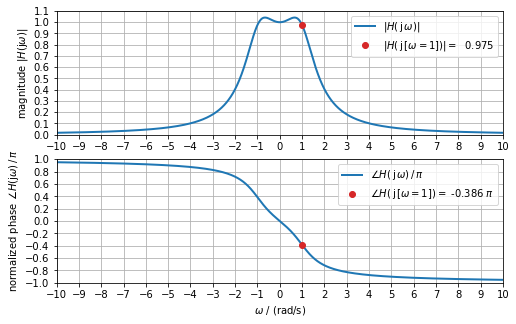

In [25]:
w0 = 5/4
D = 3/5

Q = 1/(2*D)
print('D=', D, 'Q=', Q)

w = np.linspace(-10, 10, 2**10)
s = 1j*w  # eval Fourier transform
H = 1 / (s**2/w0**2 + 2*D/w0*s + 1)

# for omega = 1
wdes = 1
Hdes = 1 / ((1j*wdes)**2/w0**2 + 2*D/w0*(1j*wdes) + 1)
np.abs(Hdes)
np.angle(Hdes)


plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.plot(w, np.abs(H), 'C0', lw=2, label=r'$|H(\,\mathrm{j}\,\omega)|$')
plt.plot(wdes, np.abs(Hdes), 'C3o',
         label=r'$|H(\,\mathrm{j}\,[\omega=1])|=$ % 4.3f' % np.abs(Hdes))
#plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'magnitude $|H(\mathrm{j}\omega)|$')
plt.xticks(np.arange(-10, 11))
plt.yticks(np.arange(0, 12)/10)
plt.xlim(-10, 10)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(w, np.angle(H)/np.pi, 'C0', lw=2,
         label=r'$\angle H(\,\mathrm{j}\,\omega) \, / \, \pi$')
plt.plot(wdes, np.angle(Hdes)/np.pi, 'C3o',
         label=r'$\angle H(\,\mathrm{j}\,[\omega=1])=$ % 4.3f $\pi$' % (np.angle(Hdes)/np.pi))
plt.xlabel(r'$\omega$ / (rad/s)')
plt.ylabel(r'normalized phase $\angle H(\mathrm{j}\omega) \, / \, \pi$')
plt.xticks(np.arange(-10, 11))
plt.yticks(np.arange(-10, 10)/5)
plt.xlim(-10, 10)
plt.ylim(-1, 1)
plt.legend()
plt.grid(True)
plt.savefig('frequency_response_mag_phase_839973EF5D.pdf')

## Copyright

This tutorial is provided as Open Educational Resource (OER), to be found at
https://github.com/spatialaudio/signals-and-systems-exercises
accompanying the OER lecture
https://github.com/spatialaudio/signals-and-systems-lecture.
Both are licensed under a) the Creative Commons Attribution 4.0 International
License for text and graphics and b) the MIT License for source code.
Please attribute material from the tutorial as *Frank Schultz,
Continuous- and Discrete-Time Signals and Systems - A Tutorial Featuring
Computational Examples, University of Rostock* with
``github URL, commit number and/or version tag, year, (file name and/or content)``.